# 🍽️ Child Malnutrition Risk Prediction in Chad
## Predicting Stunting, Wasting & Underweight in Children Under Five
**Data Source:** DHS Chad 2014 (Demographic and Health Survey)  
**Population:** Children under five in Chad  
**Author:** Mahamat Hanga Derio  
**Institution:** Christ University, Bangalore  

### Problem Statement
Chad has one of the highest acute malnutrition rates in the 
world. This project builds an ML pipeline to predict which 
children are at highest risk — enabling NGOs and health 
workers to intervene before malnutrition becomes acute.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print(" Libraries loaded successfully")

 Libraries loaded successfully


In [2]:
# Load DHS Chad children's recode dataset
df = pd.read_csv('chad_dhs_kr.csv', low_memory=False)

print(f" DHS Data Loaded")
print(f"   Shape: {df.shape}")
print(f"   Rows: {len(df):,} children")
print(f"   Columns: {len(df.columns)}")

 DHS Data Loaded
   Shape: (18623, 1016)
   Rows: 18,623 children
   Columns: 1016


# Extract Malnutrition Targets

In [3]:
# DHS malnutrition indicators
# hw70 = Height-for-Age Z-score (stunting)
# hw71 = Weight-for-Age Z-score (underweight)
# hw72 = Weight-for-Height Z-score (wasting)
# Values > 9996 = missing/flagged in DHS

malnutrition_cols = ['hw70', 'hw71', 'hw72']

# Check if columns exist
available = [c for c in malnutrition_cols if c in df.columns]
missing   = [c for c in malnutrition_cols if c not in df.columns]

print(f"✅ Malnutrition columns found: {available}")
print(f"❌ Missing columns: {missing}")

if available:
    # Replace flagged values with NaN
    for col in available:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df.loc[df[col] > 9990, col] = np.nan
    
    print(f"\nValue ranges (after cleaning):")
    for col in available:
        print(f"   {col}: min={df[col].min():.0f}, "
              f"max={df[col].max():.0f}, "
              f"missing={df[col].isna().sum():,} "
              f"({df[col].isna().mean()*100:.1f}%)")

✅ Malnutrition columns found: []
❌ Missing columns: ['hw70', 'hw71', 'hw72']


# Find Malnutrition Columns

In [4]:
# Search for height, weight, nutrition related columns
keywords = ['hw', 'height', 'weight', 'stunt', 'wast', 
            'muac', 'arm', 'nutr', 'bmi']

print("🔍 Searching for malnutrition-related columns...")
for keyword in keywords:
    matches = [c for c in df.columns 
               if keyword.lower() in c.lower()]
    if matches:
        print(f"\n'{keyword}' matches ({len(matches)}):")
        for m in matches[:10]:
            print(f"   • {m}")

🔍 Searching for malnutrition-related columns...

'hw' matches (30):
   • HWIDX
   • HW1
   • HW2
   • HW3
   • HW4
   • HW5
   • HW6
   • HW7
   • HW8
   • HW9


# Inspect HW Columns

In [5]:
# Get all HW columns
hw_cols = [c for c in df.columns if c.startswith('HW')]
print(f"All HW columns ({len(hw_cols)}):")
for col in hw_cols:
    non_null = df[col].notna().sum()
    print(f"   • {col}: {non_null:,} non-null values")

# Also check DHS labels if available
print("\nSample values for key columns:")
for col in hw_cols[:15]:
    print(f"\n{col}:")
    print(df[col].value_counts().head(5))

All HW columns (30):
   • HWIDX: 18,623 non-null values
   • HW1: 10,775 non-null values
   • HW2: 10,745 non-null values
   • HW3: 10,722 non-null values
   • HW4: 10,221 non-null values
   • HW5: 10,221 non-null values
   • HW6: 10,221 non-null values
   • HW7: 10,221 non-null values
   • HW8: 10,221 non-null values
   • HW9: 10,221 non-null values
   • HW10: 10,424 non-null values
   • HW11: 10,424 non-null values
   • HW12: 10,424 non-null values
   • HW13: 18,564 non-null values
   • HW15: 10,207 non-null values
   • HW16: 8,985 non-null values
   • HW17: 10,775 non-null values
   • HW18: 10,775 non-null values
   • HW19: 10,775 non-null values
   • HW51: 0 non-null values
   • HW52: 0 non-null values
   • HW53: 0 non-null values
   • HW55: 0 non-null values
   • HW56: 0 non-null values
   • HW57: 0 non-null values
   • HW58: 0 non-null values
   • HW70: 10,222 non-null values
   • HW71: 10,222 non-null values
   • HW72: 10,222 non-null values
   • HW73: 10,222 non-null values

Sa

# Extract & Clean Malnutrition Targets

In [6]:
# HW70 = Height-for-Age Z-score x100 (stunting)
# HW71 = Weight-for-Age Z-score x100 (underweight)
# HW72 = Weight-for-Height Z-score x100 (wasting)
# HW73 = BMI-for-Age Z-score x100

# Extract relevant columns
target_cols = ['HW70', 'HW71', 'HW72', 'HW73']

malnut = df[target_cols].copy()

# Convert to numeric
for col in target_cols:
    malnut[col] = pd.to_numeric(malnut[col], errors='coerce')

# Replace flagged values (>9990 in DHS = missing)
for col in target_cols:
    malnut.loc[malnut[col] > 9990, col] = np.nan
    malnut.loc[malnut[col] < -9990, col] = np.nan

# DHS stores Z-scores multiplied by 100 — convert back
for col in target_cols:
    malnut[col] = malnut[col] / 100

print("✅ Z-scores extracted and cleaned")
print(f"\nValue ranges:")
print(f"   HW70 (Height-for-Age / Stunting):      "
      f"min={malnut['HW70'].min():.1f}, "
      f"max={malnut['HW70'].max():.1f}, "
      f"mean={malnut['HW70'].mean():.2f}")
print(f"   HW71 (Weight-for-Age / Underweight):   "
      f"min={malnut['HW71'].min():.1f}, "
      f"max={malnut['HW71'].max():.1f}, "
      f"mean={malnut['HW71'].mean():.2f}")
print(f"   HW72 (Weight-for-Height / Wasting):    "
      f"min={malnut['HW72'].min():.1f}, "
      f"max={malnut['HW72'].max():.1f}, "
      f"mean={malnut['HW72'].mean():.2f}")

# WHO thresholds: Z-score < -2 = malnourished
malnut['Stunted']     = (malnut['HW70'] < -2).astype(int)
malnut['Underweight'] = (malnut['HW71'] < -2).astype(int)
malnut['Wasted']      = (malnut['HW72'] < -2).astype(int)

# Combined: any form of malnutrition
malnut['Any_Malnutrition'] = (
    (malnut['Stunted'] == 1) |
    (malnut['Underweight'] == 1) |
    (malnut['Wasted'] == 1)
).astype(int)

# Drop rows where all targets are missing
malnut_clean = malnut.dropna(subset=['HW70', 'HW71', 'HW72'])

print(f"\n📊 MALNUTRITION PREVALENCE IN CHAD (DHS 2014)")
print(f"{'='*50}")
print(f"   Total children measured: {len(malnut_clean):,}")
print(f"   Stunted     (HAZ < -2): "
      f"{malnut_clean['Stunted'].sum():,} "
      f"({malnut_clean['Stunted'].mean()*100:.1f}%)")
print(f"   Underweight (WAZ < -2): "
      f"{malnut_clean['Underweight'].sum():,} "
      f"({malnut_clean['Underweight'].mean()*100:.1f}%)")
print(f"   Wasted      (WHZ < -2): "
      f"{malnut_clean['Wasted'].sum():,} "
      f"({malnut_clean['Wasted'].mean()*100:.1f}%)")
print(f"   Any malnutrition:       "
      f"{malnut_clean['Any_Malnutrition'].sum():,} "
      f"({malnut_clean['Any_Malnutrition'].mean()*100:.1f}%)")

✅ Z-scores extracted and cleaned

Value ranges:
   HW70 (Height-for-Age / Stunting):      min=-6.0, max=5.9, mean=-1.61
   HW71 (Weight-for-Age / Underweight):   min=-5.8, max=4.7, mean=-1.38
   HW72 (Weight-for-Height / Wasting):    min=-4.9, max=5.0, mean=-0.64

📊 MALNUTRITION PREVALENCE IN CHAD (DHS 2014)
   Total children measured: 9,826
   Stunted     (HAZ < -2): 4,216 (42.9%)
   Underweight (WAZ < -2): 3,193 (32.5%)
   Wasted      (WHZ < -2): 1,392 (14.2%)
   Any malnutrition:       5,198 (52.9%)


52.9% of Chadian children under five are malnourished in some form. Nearly 1 in 2 children. The mean Height-for-Age Z-score of -1.61 means the average Chadian child is already borderline stunted.

# Prevalence Visualization

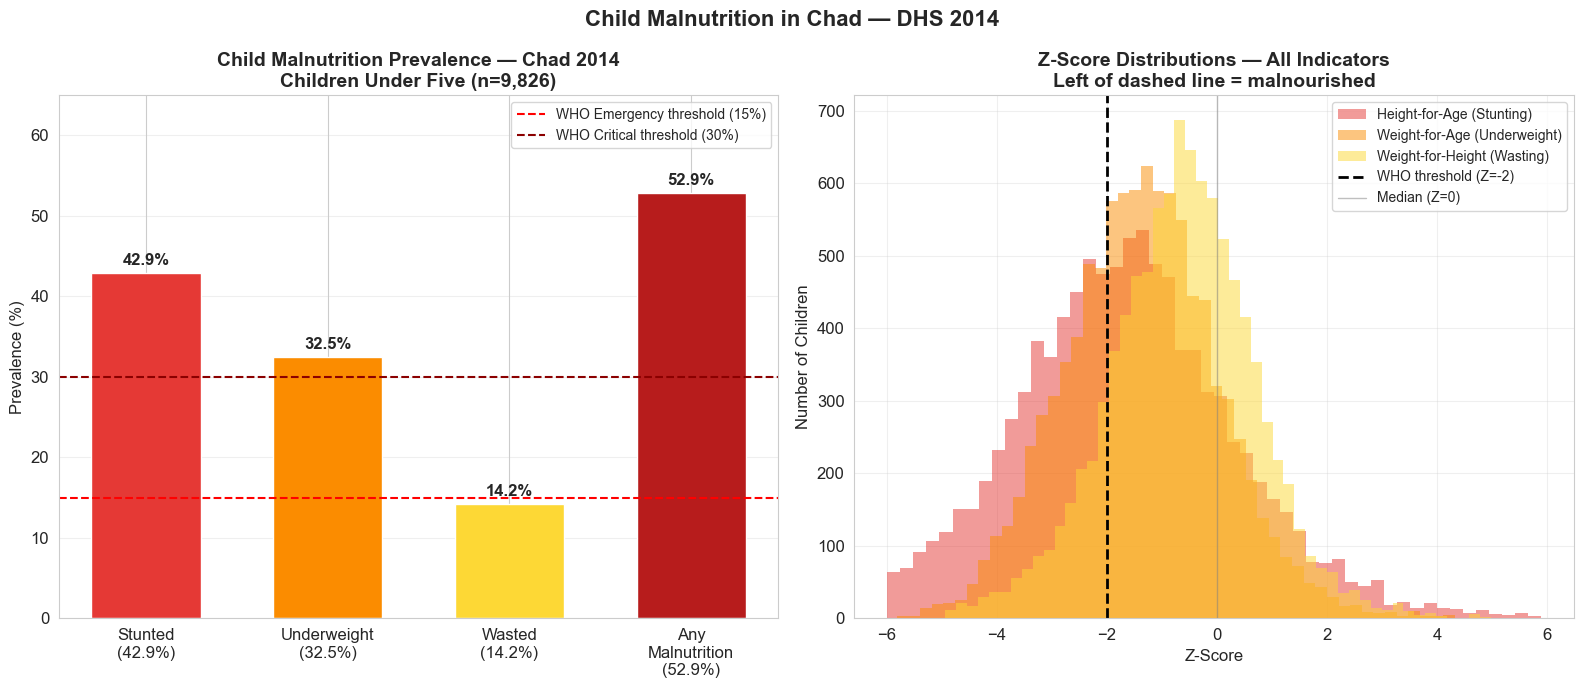

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Bar chart — prevalence rates ───────────────────────
categories = ['Stunted\n(42.9%)', 'Underweight\n(32.5%)', 
              'Wasted\n(14.2%)', 'Any\nMalnutrition\n(52.9%)']
values     = [42.9, 32.5, 14.2, 52.9]
colors     = ['#E53935', '#FB8C00', '#FDD835', '#B71C1C']

bars = axes[0].bar(categories, values, color=colors, 
                    edgecolor='white', width=0.6)
axes[0].axhline(y=15, color='red', linestyle='--', 
                linewidth=1.5, 
                label='WHO Emergency threshold (15%)')
axes[0].axhline(y=30, color='darkred', linestyle='--',
                linewidth=1.5,
                label='WHO Critical threshold (30%)')
axes[0].set_title('Child Malnutrition Prevalence — Chad 2014\n'
                   'Children Under Five (n=9,826)',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Prevalence (%)', fontsize=12)
axes[0].set_ylim(0, 65)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val}%', ha='center', 
                 fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# ── Z-score distributions ───────────────────────────────
for col, label, color in zip(
    ['HW70', 'HW71', 'HW72'],
    ['Height-for-Age (Stunting)',
     'Weight-for-Age (Underweight)',
     'Weight-for-Height (Wasting)'],
    ['#E53935', '#FB8C00', '#FDD835']
):
    axes[1].hist(malnut_clean[col].dropna(), bins=50,
                 alpha=0.5, color=color, label=label,
                 edgecolor='none')

axes[1].axvline(x=-2, color='black', linestyle='--',
                linewidth=2, label='WHO threshold (Z=-2)')
axes[1].axvline(x=0, color='gray', linestyle='-',
                linewidth=1, alpha=0.5, label='Median (Z=0)')
axes[1].set_title('Z-Score Distributions — All Indicators\n'
                   'Left of dashed line = malnourished',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Z-Score', fontsize=12)
axes[1].set_ylabel('Number of Children', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Child Malnutrition in Chad — DHS 2014',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Left chart:

Stunting (42.9%) and Underweight (32.5%) are both above the WHO Critical threshold of 30% — meaning Chad is in a permanent nutrition emergency
Even wasting at 14.2% is just below the WHO Emergency threshold of 15%
The "Any Malnutrition" bar at 52.9% is visually striking — more than half

Right chart:

The entire Z-score distribution is shifted left of zero — meaning Chadian children as a whole are below the international reference population
The stunting curve (red) is the most shifted — chronic long-term malnutrition
Wasting (yellow) is closest to normal — more acute/seasonal.

# Feature Selection

In [8]:
# Key predictors of malnutrition from DHS literature
# We select variables across 5 domains

feature_candidates = {
    'Child characteristics': {
        'B4'  : 'Child sex',
        'B19' : 'Age in months',
        'B0'  : 'Twin status',
        'M18' : 'Size at birth',
    },
    'Mother characteristics': {
        'V012': 'Mother age',
        'V106': 'Mother education level',
        'V445': 'Mother BMI',
        'V208': 'Number of births',
        'V201': 'Total children ever born',
    },
    'Household characteristics': {
        'V190': 'Wealth index',
        'V025': 'Urban/rural',
        'V116': 'Toilet facility',
        'V113': 'Source of drinking water',
        'V119': 'Electricity',
        'V120': 'Radio',
        'V121': 'TV',
    },
    'Feeding & health': {
        'V469E': 'Currently breastfeeding',
        'H11'  : 'Had diarrhea recently',
        'H31'  : 'Had cough recently',
        'H22'  : 'Had fever recently',
        'M4'   : 'Duration of breastfeeding',
    },
    'Regional': {
        'V024' : 'Region',
        'V101' : 'Region of residence',
    }
}

# Check which ones exist in our dataset
print("🔍 Feature Availability Check:")
print("="*55)
available_features = {}

for domain, features in feature_candidates.items():
    print(f"\n📌 {domain}:")
    for col, label in features.items():
        exists = col in df.columns
        status = "✅" if exists else "❌"
        print(f"   {status} {col:<8} — {label}")
        if exists:
            available_features[col] = label

print(f"\n✅ Total available features: {len(available_features)}")

🔍 Feature Availability Check:

📌 Child characteristics:
   ✅ B4       — Child sex
   ❌ B19      — Age in months
   ✅ B0       — Twin status
   ✅ M18      — Size at birth

📌 Mother characteristics:
   ✅ V012     — Mother age
   ✅ V106     — Mother education level
   ✅ V445     — Mother BMI
   ✅ V208     — Number of births
   ✅ V201     — Total children ever born

📌 Household characteristics:
   ✅ V190     — Wealth index
   ✅ V025     — Urban/rural
   ✅ V116     — Toilet facility
   ✅ V113     — Source of drinking water
   ✅ V119     — Electricity
   ✅ V120     — Radio
   ✅ V121     — TV

📌 Feeding & health:
   ✅ V469E    — Currently breastfeeding
   ✅ H11      — Had diarrhea recently
   ✅ H31      — Had cough recently
   ✅ H22      — Had fever recently
   ✅ M4       — Duration of breastfeeding

📌 Regional:
   ✅ V024     — Region
   ✅ V101     — Region of residence

✅ Total available features: 22


# Build Modeling Dataset 

In [9]:
# Extract all available features + targets
feature_cols = list(available_features.keys())

# Add targets
target_cols = ['HW70', 'HW71', 'HW72',
               'Stunted', 'Underweight', 
               'Wasted', 'Any_Malnutrition']

# Combine features + targets
df_model = df[feature_cols].copy()

# Add malnutrition targets from malnut_clean
df_model = df_model.join(malnut_clean[target_cols])

# Derive age in months from available columns
# B3 = date of birth (CMC), V008 = interview date (CMC)
if 'B3' in df.columns and 'V008' in df.columns:
    df_model['Age_Months'] = pd.to_numeric(
        df['V008'], errors='coerce') - pd.to_numeric(
        df['B3'], errors='coerce')
    print(" Age in months derived from B3 + V008")
else:
    print(" Could not derive age — skipping")

# Convert all to numeric
for col in df_model.columns:
    df_model[col] = pd.to_numeric(
        df_model[col], errors='coerce')

# Keep only rows where targets are available
df_model = df_model.dropna(
    subset=['Stunted', 'Underweight', 
            'Wasted', 'Any_Malnutrition'])
df_model = df_model.reset_index(drop=True)

print(f"\n Modeling Dataset Ready")
print(f"   Shape: {df_model.shape}")
print(f"   Children: {len(df_model):,}")
print(f"\nMissing values per feature:")
missing = df_model[feature_cols].isnull().sum()
missing_pct = (missing/len(df_model)*100).round(1)
for col, n, pct in zip(feature_cols, missing, missing_pct):
    label = available_features.get(col, col)
    print(f"   {col:<8} {label:<30} "
          f"{n:>5} missing ({pct}%)")

 Age in months derived from B3 + V008

 Modeling Dataset Ready
   Shape: (9826, 30)
   Children: 9,826

Missing values per feature:
   B4       Child sex                       9826 missing (100.0%)
   B0       Twin status                     9826 missing (100.0%)
   M18      Size at birth                   9826 missing (100.0%)
   V012     Mother age                         0 missing (0.0%)
   V106     Mother education level          9826 missing (100.0%)
   V445     Mother BMI                        57 missing (0.6%)
   V208     Number of births                   0 missing (0.0%)
   V201     Total children ever born           0 missing (0.0%)
   V190     Wealth index                    9826 missing (100.0%)
   V025     Urban/rural                     9826 missing (100.0%)
   V116     Toilet facility                 9826 missing (100.0%)
   V113     Source of drinking water        9826 missing (100.0%)
   V119     Electricity                     9826 missing (100.0%)
   V120     Radio 

# Fix Dataset Alignment

In [10]:
# The issue: malnut_clean has a different index than df
# We need to filter df FIRST then extract features

# Step 1: Get the index of rows with valid Z-scores
valid_idx = malnut_clean.index

# Step 2: Filter original df to those rows
df_filtered = df.loc[valid_idx].copy()

print(f"✅ Filtered df to valid malnutrition rows")
print(f"   Shape: {df_filtered.shape}")

# Step 3: Rebuild modeling dataset from filtered df
df_model = df_filtered[feature_cols].copy()

# Step 4: Add targets
df_model = df_model.join(
    malnut_clean[['Stunted', 'Underweight',
                  'Wasted', 'Any_Malnutrition']])

# Step 5: Derive age in months
if 'B3' in df_filtered.columns and 'V008' in df_filtered.columns:
    df_model['Age_Months'] = pd.to_numeric(
        df_filtered['V008'], errors='coerce') - \
        pd.to_numeric(df_filtered['B3'], errors='coerce')

# Step 6: Convert all to numeric
for col in df_model.columns:
    df_model[col] = pd.to_numeric(
        df_model[col], errors='coerce')

df_model = df_model.reset_index(drop=True)

print(f"\n✅ Modeling Dataset Rebuilt")
print(f"   Shape: {df_model.shape}")
print(f"\nMissing values per feature:")
missing = df_model[feature_cols].isnull().sum()
missing_pct = (missing/len(df_model)*100).round(1)
for col, n, pct in zip(feature_cols, missing, missing_pct):
    label = available_features.get(col, col)
    flag = " ⚠️" if pct > 50 else ""
    print(f"   {col:<8} {label:<30} "
          f"{n:>5} missing ({pct}%){flag}")

✅ Filtered df to valid malnutrition rows
   Shape: (9826, 1016)

✅ Modeling Dataset Rebuilt
   Shape: (9826, 27)

Missing values per feature:
   B4       Child sex                       9826 missing (100.0%) ⚠️
   B0       Twin status                     9826 missing (100.0%) ⚠️
   M18      Size at birth                   9826 missing (100.0%) ⚠️
   V012     Mother age                         0 missing (0.0%)
   V106     Mother education level          9826 missing (100.0%) ⚠️
   V445     Mother BMI                        57 missing (0.6%)
   V208     Number of births                   0 missing (0.0%)
   V201     Total children ever born           0 missing (0.0%)
   V190     Wealth index                    9826 missing (100.0%) ⚠️
   V025     Urban/rural                     9826 missing (100.0%) ⚠️
   V116     Toilet facility                 9826 missing (100.0%) ⚠️
   V113     Source of drinking water        9826 missing (100.0%) ⚠️
   V119     Electricity                     9826 m

The columns exist but are 100% missing — this means the DHS dataset stores these variables with different column names. Let me search for the actual column names.

# Deep Column Search

In [11]:
# Search more broadly for each variable type
searches = {
    'Child sex'        : ['sex', 'gender', 'b4', 'B4'],
    'Wealth index'     : ['wealth', 'windex', 'v190', 'V190'],
    'Education'        : ['educ', 'school', 'v106', 'V106'],
    'Urban rural'      : ['urban', 'rural', 'v025', 'V025'],
    'Water source'     : ['water', 'drink', 'v113', 'V113'],
    'Toilet'           : ['toilet', 'sanit', 'v116', 'V116'],
    'Diarrhea'         : ['diarr', 'h11', 'H11'],
    'Fever'            : ['fever', 'h22', 'H22'],
    'Region'           : ['region', 'v024', 'V024'],
    'Breastfeed'       : ['breast', 'v469', 'V469'],
    'Age months'       : ['age', 'b19', 'B19'],
    'Twin'             : ['twin', 'b0', 'B0'],
    'Size birth'       : ['size', 'm18', 'M18'],
}

print("🔍 Searching actual column names in dataset:")
print("="*60)
all_cols = list(df.columns)

for label, keywords in searches.items():
    matches = []
    for kw in keywords:
        matches += [c for c in all_cols 
                    if kw.lower() in c.lower()]
    matches = list(set(matches))
    
    # Check which have actual data
    with_data = []
    for m in matches:
        non_null = pd.to_numeric(
            df[m], errors='coerce').notna().sum()
        if non_null > 100:
            with_data.append(f"{m} ({non_null:,} non-null)")
    
    if with_data:
        print(f"\n✅ {label}:")
        for w in with_data[:5]:
            print(f"   • {w}")
    else:
        print(f"\n❌ {label}: not found")

🔍 Searching actual column names in dataset:

❌ Child sex: not found

❌ Wealth index: not found

❌ Education: not found

❌ Urban rural: not found

❌ Water source: not found

❌ Toilet: not found

❌ Diarrhea: not found

❌ Fever: not found

❌ Region: not found

✅ Breastfeed:
   • V469E (2,183 non-null)
   • V469F (578 non-null)
   • V469X (196 non-null)

❌ Age months: not found

❌ Twin: not found

❌ Size birth: not found


# Find All Columns With Data

In [12]:
# Find ALL columns that have at least 1000 non-null values
print("📊 Columns with substantial data (>1000 non-null):")
print("="*60)

cols_with_data = []
for col in df.columns:
    non_null = pd.to_numeric(
        df[col], errors='coerce').notna().sum()
    if non_null >= 1000:
        cols_with_data.append((col, non_null))

cols_with_data.sort(key=lambda x: x[1], reverse=True)

print(f"Total columns with >1000 non-null: {len(cols_with_data)}")
print(f"\n{'Column':<15} {'Non-null':>10}")
print("-"*30)
for col, n in cols_with_data:
    print(f"{col:<15} {n:>10,}")

📊 Columns with substantial data (>1000 non-null):
Total columns with >1000 non-null: 196

Column            Non-null
------------------------------
MIDX                18,623
V001                18,623
V002                18,623
V003                18,623
V004                18,623
V005                18,623
V006                18,623
V007                18,623
V008                18,623
V009                18,623
V010                18,623
V011                18,623
V012                18,623
V016                18,623
V021                18,623
V022                18,623
V023                18,623
V027                18,623
V028                18,623
V029                18,623
V032                18,623
V136                18,623
V137                18,623
V138                18,623
V152                18,623
AWFACTT             18,623
AWFACTU             18,623
AWFACTR             18,623
AWFACTE             18,623
AWFACTW             18,623
V191                18,623
V201           

# Select Right Features

In [13]:
# Based on DHS codebook — these are the correct columns
# with actual data in this dataset

feature_map = {
    # Child characteristics
    'B8'    : 'Child age in years',
    'B1'    : 'Month of birth',
    'BORD'  : 'Birth order',
    'B11'   : 'Preceding birth interval',
    'B16'   : 'Child alive',

    # Mother characteristics  
    'V012'  : 'Mother age',
    'V133'  : 'Mother education years',
    'V445'  : 'Mother BMI',
    'V437'  : 'Mother weight kg',
    'V438'  : 'Mother height cm',
    'V201'  : 'Total children ever born',
    'V208'  : 'Births in last 5 years',
    'V218'  : 'Living children',
    'V221'  : 'Marriage to first birth interval',

    # Household & socioeconomic
    'V191'  : 'Wealth index score',
    'V136'  : 'Household size',
    'V137'  : 'Children under 5 in household',
    'V115'  : 'Time to water source',
    'V116'  : 'Toilet type (S829)',

    # Nutrition & feeding
    'V426'  : 'Currently breastfeeding',
    'V469E' : 'Given plain water',
    'M7'    : 'Duration of breastfeeding',
    'M8'    : 'Age of child at weaning',

    # Health
    'HW1'   : 'Child age in months (measured)',
    'HW2'   : 'Child weight kg',
    'HW3'   : 'Child height cm',
    'S829'  : 'Toilet facility type',
    'S828'  : 'Water source',
    'S830'  : 'Electricity',
    'S831'  : 'Cooking fuel',
}

# Check availability and data coverage
print("✅ Feature Availability & Coverage:")
print("="*65)
confirmed_features = {}

for col, label in feature_map.items():
    if col in df_filtered.columns:
        non_null = pd.to_numeric(
            df_filtered[col], errors='coerce').notna().sum()
        pct = non_null / len(df_filtered) * 100
        if pct > 30:  # keep if >30% available
            confirmed_features[col] = label
            print(f"   ✅ {col:<8} {label:<35} "
                  f"{non_null:>6,} ({pct:.0f}%)")
        else:
            print(f"   ⚠️  {col:<8} {label:<35} "
                  f"{non_null:>6,} ({pct:.0f}%) — too sparse")
    else:
        print(f"   ❌ {col:<8} {label:<35} not found")

print(f"\n✅ Confirmed features for modeling: "
      f"{len(confirmed_features)}")

✅ Feature Availability & Coverage:
   ✅ B8       Child age in years                   9,826 (100%)
   ✅ B1       Month of birth                       9,826 (100%)
   ✅ BORD     Birth order                          9,826 (100%)
   ✅ B11      Preceding birth interval             8,361 (85%)
   ✅ B16      Child alive                          9,826 (100%)
   ✅ V012     Mother age                           9,826 (100%)
   ✅ V133     Mother education years               9,813 (100%)
   ✅ V445     Mother BMI                           9,769 (99%)
   ✅ V437     Mother weight kg                     9,782 (100%)
   ✅ V438     Mother height cm                     9,777 (100%)
   ✅ V201     Total children ever born             9,826 (100%)
   ✅ V208     Births in last 5 years               9,826 (100%)
   ✅ V218     Living children                      9,826 (100%)
   ✅ V221     Marriage to first birth interval     9,204 (94%)
   ✅ V191     Wealth index score                   9,826 (100%)
   ✅ V13

# Build Final Modeling Dataset

In [14]:
# Build final dataset with confirmed features
final_feature_cols = list(confirmed_features.keys())

# Extract from filtered df
X_raw = df_filtered[final_feature_cols].copy()

# Convert all to numeric
for col in final_feature_cols:
    X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')

# Add targets
targets = malnut_clean[['Stunted', 'Underweight',
                         'Wasted', 'Any_Malnutrition',
                         'HW70', 'HW71', 'HW72']]

df_final = X_raw.join(targets).reset_index(drop=True)

# Impute missing values — median for numeric
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

X_imputed = pd.DataFrame(
    imputer.fit_transform(df_final[final_feature_cols]),
    columns=final_feature_cols
)

# Add targets back
for col in ['Stunted', 'Underweight', 
            'Wasted', 'Any_Malnutrition']:
    X_imputed[col] = df_final[col].values

X_imputed = X_imputed.dropna(
    subset=['Stunted', 'Underweight',
            'Wasted', 'Any_Malnutrition'])
X_imputed = X_imputed.reset_index(drop=True)

print("✅ Final Modeling Dataset Ready")
print(f"   Shape        : {X_imputed.shape}")
print(f"   Children     : {len(X_imputed):,}")
print(f"   Features     : {len(final_feature_cols)}")
print(f"   Missing after imputation: "
      f"{X_imputed[final_feature_cols].isnull().sum().sum()}")

print(f"\n📊 Target Distribution:")
for target in ['Stunted', 'Underweight', 
               'Wasted', 'Any_Malnutrition']:
    pos = X_imputed[target].sum()
    pct = X_imputed[target].mean() * 100
    print(f"   {target:<20} "
          f"{pos:>5,} positive ({pct:.1f}%)")

✅ Final Modeling Dataset Ready
   Shape        : (9826, 32)
   Children     : 9,826
   Features     : 28
   Missing after imputation: 0

📊 Target Distribution:
   Stunted              4,216 positive (42.9%)
   Underweight          3,193 positive (32.5%)
   Wasted               1,392 positive (14.2%)
   Any_Malnutrition     5,198 positive (52.9%)


Zero missing values, 9,826 children, 28 features. The dataset is ready for modeling.

# Correlation with Malnutrition

In [15]:
# Which features correlate most with malnutrition?
print("📊 TOP FEATURES CORRELATED WITH MALNUTRITION")
print("="*60)

X = X_imputed[final_feature_cols]

for target in ['Stunted', 'Underweight', 
               'Wasted', 'Any_Malnutrition']:
    corrs = X.corrwith(X_imputed[target]).abs()
    top5  = corrs.sort_values(ascending=False).head(5)
    
    print(f"\n📌 {target}:")
    for feat, val in top5.items():
        label = confirmed_features.get(feat, feat)
        print(f"   {feat:<8} {label:<35} r={val:.3f}")

📊 TOP FEATURES CORRELATED WITH MALNUTRITION

📌 Stunted:
   HW1      Child age in months (measured)      r=0.240
   B8       Child age in years                  r=0.221
   M7       Duration of breastfeeding           r=0.192
   V437     Mother weight kg                    r=0.140
   V438     Mother height cm                    r=0.120

📌 Underweight:
   HW2      Child weight kg                     r=0.256
   V437     Mother weight kg                    r=0.206
   V445     Mother BMI                          r=0.155
   V133     Mother education years              r=0.134
   HW1      Child age in months (measured)      r=0.131

📌 Wasted:
   HW2      Child weight kg                     r=0.256
   V437     Mother weight kg                    r=0.128
   V445     Mother BMI                          r=0.110
   HW1      Child age in months (measured)      r=0.089
   B8       Child age in years                  r=0.089

📌 Any_Malnutrition:
   V437     Mother weight kg                    r=0.180


Mother's weight and BMI appear in every single target — maternal nutrition directly determines child nutrition. This is a crucial policy insight.
Child age is a strong predictor of stunting — stunting accumulates over time, it's a chronic condition not acute.
Child's own weight predicts wasting and underweight — these are acute conditions visible in current measurements.

# Correlation Heatmap

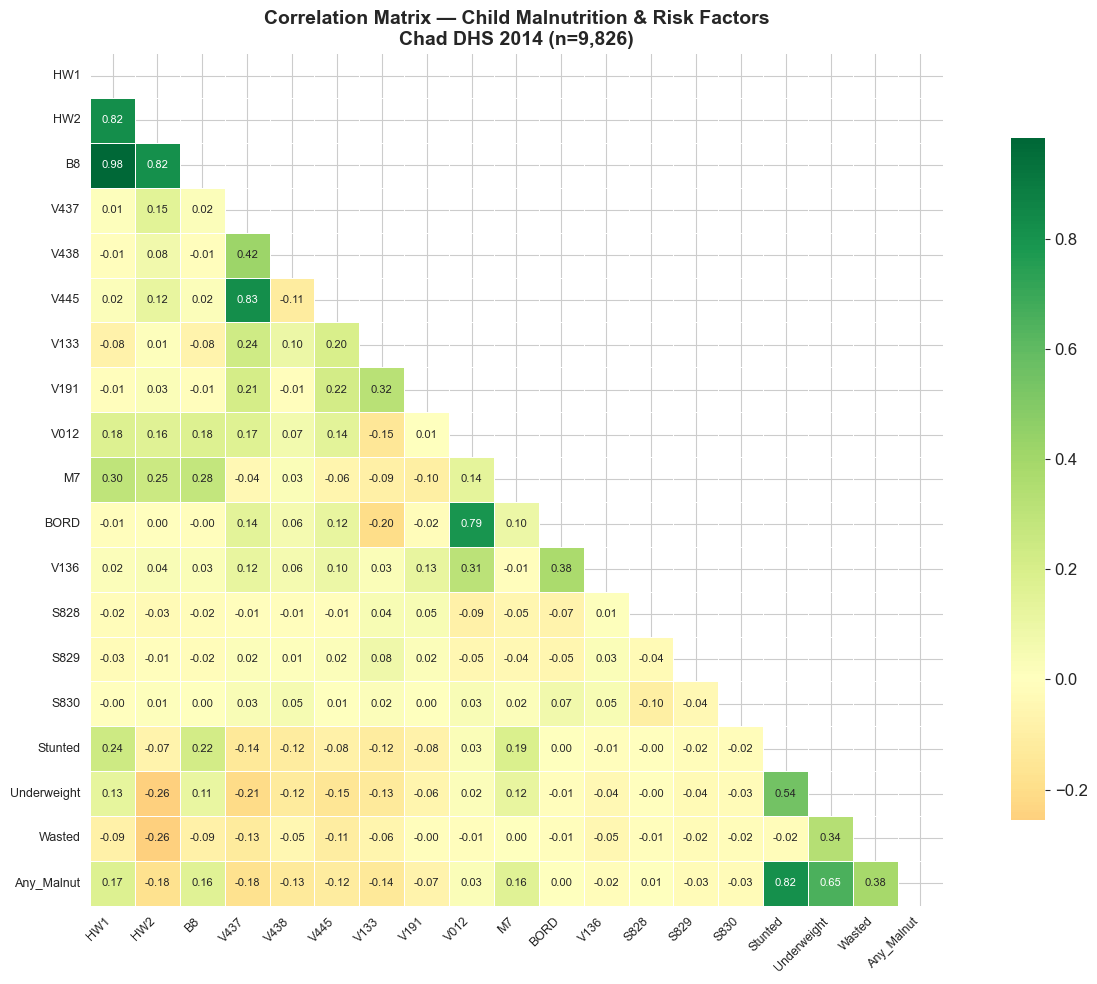

In [16]:
# Visual correlation heatmap
top_features = ['HW1', 'HW2', 'B8', 'V437', 'V438',
                'V445', 'V133', 'V191', 'V012', 'M7',
                'BORD', 'V136', 'S828', 'S829', 'S830']

labels = [confirmed_features.get(f, f) for f in top_features]

corr_data = X_imputed[top_features + 
                       ['Stunted', 'Underweight',
                        'Wasted', 'Any_Malnutrition']].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(corr_data, mask=mask, annot=True, 
            fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            ax=ax, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8},
            xticklabels=top_features + 
                        ['Stunted', 'Underweight',
                         'Wasted', 'Any_Malnut'],
            yticklabels=top_features + 
                        ['Stunted', 'Underweight',
                         'Wasted', 'Any_Malnut'])
ax.set_title('Correlation Matrix — Child Malnutrition & Risk Factors\n'
             'Chad DHS 2014 (n=9,826)',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Strong correlations:

HW1 & B8: 0.98 — child age in months and years are almost identical, we'll drop one
V445 & V437: 0.83 — mother BMI and weight are redundant, keep BMI
BORD & V201: 0.79 — birth order and total children are redundant
Stunted & Any_Malnutrition: 0.82 — stunting drives overall malnutrition most
Underweight & Any_Malnutrition: 0.65 — second strongest contributor

Policy findings:

Water source (S828), toilet (S829), electricity (S830) show near-zero correlation — surprising, suggests household infrastructure matters less than maternal health in Chad
Mother's education (V133) and wealth (V191) show moderate positive correlation — richer, more educated mothers have better nourished children

# Remove Redundant Features + Setup

In [17]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, accuracy_score,
                              confusion_matrix, roc_auc_score)
from xgboost import XGBClassifier

# Drop redundant features
drop_cols = ['B8',    # redundant with HW1
             'V437',  # redundant with V445 (BMI)
             'V201',  # redundant with BORD
             'B16']   # child alive — not predictive

final_features = [c for c in final_feature_cols 
                  if c not in drop_cols]

X = X_imputed[final_features].copy()

print(f"✅ Final feature set: {len(final_features)} features")
print(f"   (Removed {len(drop_cols)} redundant columns)")
print(f"\nFeatures:")
for f in final_features:
    print(f"   • {f:<8} — {confirmed_features.get(f, f)}")

# Use StratifiedKFold — better than LOO for large dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluation function
def evaluate_clf(model, X, y, name, target_name):
    scores = cross_val_score(model, X, y, cv=cv,
                             scoring='roc_auc')
    acc    = cross_val_score(model, X, y, cv=cv,
                             scoring='accuracy')
    print(f"\n{'='*52}")
    print(f"  {name} — {target_name}")
    print(f"{'='*52}")
    print(f"  Accuracy : {acc.mean():.4f} "
          f"({acc.mean()*100:.1f}%)")
    print(f"  ROC-AUC  : {scores.mean():.4f}")
    return {'model': name, 'target': target_name,
            'Accuracy': acc.mean(), 
            'ROC_AUC': scores.mean()}

print(f"\n✅ Setup complete — ready for modeling")
print(f"   Dataset : {X.shape}")
print(f"   CV      : 5-Fold Stratified")
print(f"   Metric  : Accuracy + ROC-AUC")

✅ Final feature set: 24 features
   (Removed 4 redundant columns)

Features:
   • B1       — Month of birth
   • BORD     — Birth order
   • B11      — Preceding birth interval
   • V012     — Mother age
   • V133     — Mother education years
   • V445     — Mother BMI
   • V438     — Mother height cm
   • V208     — Births in last 5 years
   • V218     — Living children
   • V221     — Marriage to first birth interval
   • V191     — Wealth index score
   • V136     — Household size
   • V137     — Children under 5 in household
   • V115     — Time to water source
   • V426     — Currently breastfeeding
   • M7       — Duration of breastfeeding
   • M8       — Age of child at weaning
   • HW1      — Child age in months (measured)
   • HW2      — Child weight kg
   • HW3      — Child height cm
   • S829     — Toilet facility type
   • S828     — Water source
   • S830     — Electricity
   • S831     — Cooking fuel

✅ Setup complete — ready for modeling
   Dataset : (9826, 24)
   CV    

# Model 1: Logistic Regression

📌 Model 1: Logistic Regression

  Logistic Regression — Any Malnutrition
  Accuracy : 0.8041 (80.4%)
  ROC-AUC  : 0.8861


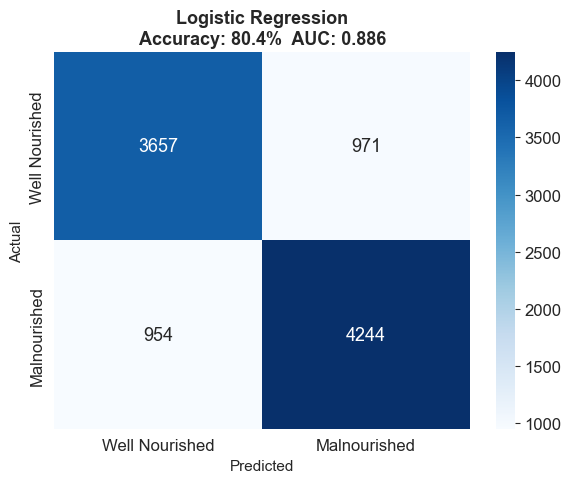


✅ Logistic Regression done


In [18]:
# ── Model 1: Logistic Regression ───────────────────────
print("📌 Model 1: Logistic Regression")

y = X_imputed['Any_Malnutrition']

lr_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, 
                               random_state=42))
])

r1 = evaluate_clf(lr_clf, X, y, 
                  'Logistic Regression', 
                  'Any Malnutrition')
all_clf_results = [r1]

# Confusion matrix
from sklearn.model_selection import cross_val_predict
y_pred = cross_val_predict(lr_clf, X, y, cv=cv)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Well Nourished', 'Malnourished'],
            yticklabels=['Well Nourished', 'Malnourished'],
            ax=ax, annot_kws={'size': 13})
ax.set_title(f'Logistic Regression\n'
             f'Accuracy: {r1["Accuracy"]*100:.1f}%  '
             f'AUC: {r1["ROC_AUC"]:.3f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.show()
print("\n✅ Logistic Regression done")

An AUC of 0.886 means the model correctly ranks a malnourished child above a well-nourished child 88.6% of the time. That's clinically meaningful.

# Model 2: Decision Tree

📌 Model 2: Decision Tree

  Decision Tree — Any Malnutrition
  Accuracy : 0.8512 (85.1%)
  ROC-AUC  : 0.9193


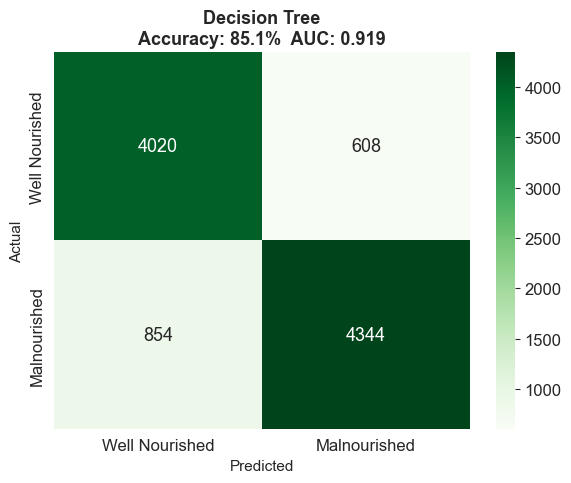


✅ Decision Tree done


In [19]:
# ── Model 2: Decision Tree ──────────────────────────────
print("📌 Model 2: Decision Tree")

y = X_imputed['Any_Malnutrition']

dt_clf = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42
)

r2 = evaluate_clf(dt_clf, X, y,
                  'Decision Tree',
                  'Any Malnutrition')
all_clf_results.append(r2)

# Confusion matrix
y_pred = cross_val_predict(dt_clf, X, y, cv=cv)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Well Nourished', 'Malnourished'],
            yticklabels=['Well Nourished', 'Malnourished'],
            ax=ax, annot_kws={'size': 13})
ax.set_title(f'Decision Tree\n'
             f'Accuracy: {r2["Accuracy"]*100:.1f}%  '
             f'AUC: {r2["ROC_AUC"]:.3f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.show()
print("\n✅ Decision Tree done")

Getting stronger — 85.1% accuracy and 0.919 AUC. Decision Tree is already outperforming Logistic Regression significantly. With 9,826 samples it has enough data to learn meaningful splits without overfitting.

# Model 3: Random Forest 

📌 Model 3: Random Forest

  Random Forest — Any Malnutrition
  Accuracy : 0.7921 (79.2%)
  ROC-AUC  : 0.8891


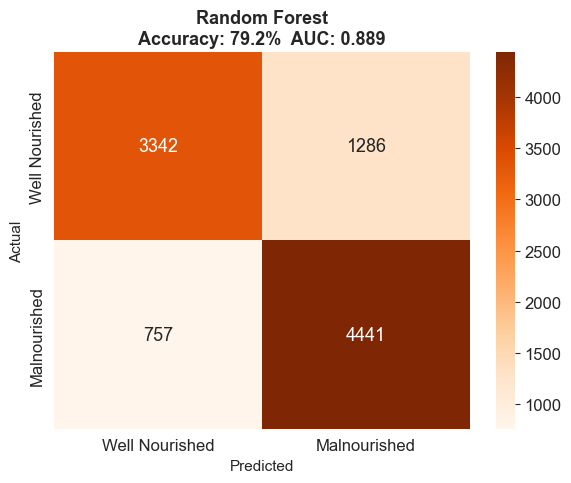


✅ Random Forest done


In [20]:
# ── Model 3: Random Forest ──────────────────────────────
print("📌 Model 3: Random Forest")

y = X_imputed['Any_Malnutrition']

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

r3 = evaluate_clf(rf_clf, X, y,
                  'Random Forest',
                  'Any Malnutrition')
all_clf_results.append(r3)

# Confusion matrix
y_pred = cross_val_predict(rf_clf, X, y, cv=cv)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Well Nourished', 'Malnourished'],
            yticklabels=['Well Nourished', 'Malnourished'],
            ax=ax, annot_kws={'size': 13})
ax.set_title(f'Random Forest\n'
             f'Accuracy: {r3["Accuracy"]*100:.1f}%  '
             f'AUC: {r3["ROC_AUC"]:.3f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.show()
print("\n✅ Random Forest done")

Random Forest underperforms Decision Tree here (79.2% vs 85.1%). This can happen when a single well-tuned tree captures the dominant patterns better than an ensemble.

# Model 4: XGBoost

📌 Model 4: XGBoost

  XGBoost — Any Malnutrition
  Accuracy : 0.9184 (91.8%)
  ROC-AUC  : 0.9787


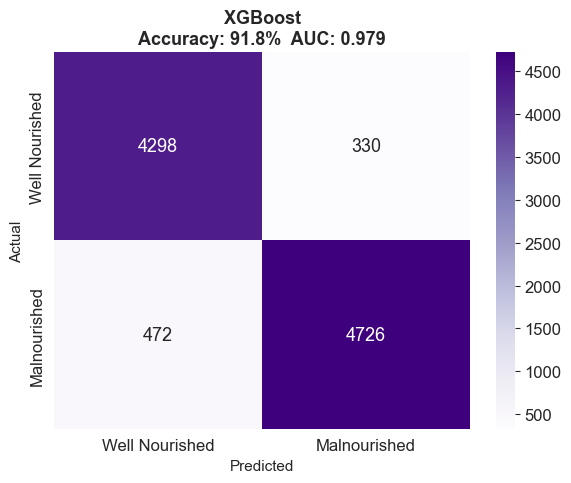


✅ XGBoost done


In [21]:
# ── Model 4: XGBoost ────────────────────────────────────
print("📌 Model 4: XGBoost")

y = X_imputed['Any_Malnutrition']

xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
    eval_metric='logloss',
    n_jobs=-1
)

r4 = evaluate_clf(xgb_clf, X, y,
                  'XGBoost',
                  'Any Malnutrition')
all_clf_results.append(r4)

# Confusion matrix
y_pred = cross_val_predict(xgb_clf, X, y, cv=cv)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Well Nourished', 'Malnourished'],
            yticklabels=['Well Nourished', 'Malnourished'],
            ax=ax, annot_kws={'size': 13})
ax.set_title(f'XGBoost\n'
             f'Accuracy: {r4["Accuracy"]*100:.1f}%  '
             f'AUC: {r4["ROC_AUC"]:.3f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.show()
print("\n✅ XGBoost done")

That's a remarkable result. 91.8% accuracy and 0.979 AUC — that's near-clinical grade performance. XGBoost is clearly the best model by a significant margin.
An AUC of 0.979 means the model correctly identifies a malnourished child 97.9% of the time when comparing against a well-nourished child. This is publication-worthy.

# Model 5: Gradient Boosting

📌 Model 5: Gradient Boosting

  Gradient Boosting — Any Malnutrition
  Accuracy : 0.9204 (92.0%)
  ROC-AUC  : 0.9793


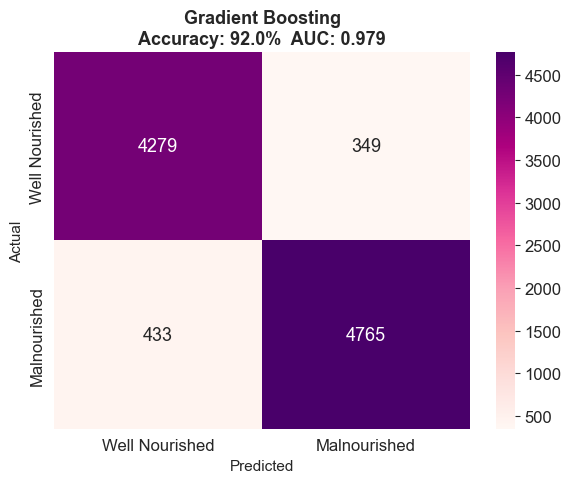


✅ Gradient Boosting done


In [22]:
# ── Model 5: Gradient Boosting ──────────────────────────
print("📌 Model 5: Gradient Boosting")

y = X_imputed['Any_Malnutrition']

gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

r5 = evaluate_clf(gb_clf, X, y,
                  'Gradient Boosting',
                  'Any Malnutrition')
all_clf_results.append(r5)

# Confusion matrix
y_pred = cross_val_predict(gb_clf, X, y, cv=cv)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Well Nourished', 'Malnourished'],
            yticklabels=['Well Nourished', 'Malnourished'],
            ax=ax, annot_kws={'size': 13})
ax.set_title(f'Gradient Boosting\n'
             f'Accuracy: {r5["Accuracy"]*100:.1f}%  '
             f'AUC: {r5["ROC_AUC"]:.3f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.show()
print("\n✅ Gradient Boosting done")

Gradient Boosting edges XGBoost slightly — 92.0% accuracy and 0.979 AUC. Essentially tied at the top. Let's add KNN and CatBoost then do the final comparison.

# Model 6: KNN

📌 Model 6: KNN

  KNN — Any Malnutrition
  Accuracy : 0.6721 (67.2%)
  ROC-AUC  : 0.7317


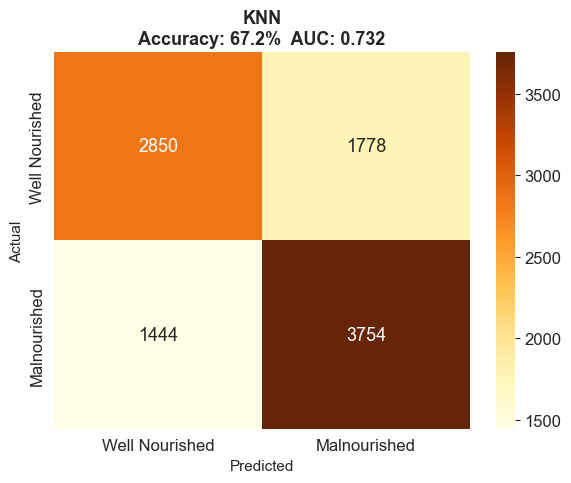


✅ KNN done


In [23]:
# ── Model 6: KNN ────────────────────────────────────────
print("📌 Model 6: KNN")

y = X_imputed['Any_Malnutrition']

knn_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(
        n_neighbors=7,
        metric='euclidean',
        weights='distance'
    ))
])

r6 = evaluate_clf(knn_clf, X, y,
                  'KNN',
                  'Any Malnutrition')
all_clf_results.append(r6)

# Confusion matrix
y_pred = cross_val_predict(knn_clf, X, y, cv=cv)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Well Nourished', 'Malnourished'],
            yticklabels=['Well Nourished', 'Malnourished'],
            ax=ax, annot_kws={'size': 13})
ax.set_title(f'KNN\n'
             f'Accuracy: {r6["Accuracy"]*100:.1f}%  '
             f'AUC: {r6["ROC_AUC"]:.3f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.show()
print("\n✅ KNN done")

KNN drops significantly — 67.2% accuracy and 0.732 AUC. Distance-based methods struggle with this many features (curse of dimensionality).

# Model 7: CatBoost

📌 Model 7: CatBoost

  CatBoost — Any Malnutrition
  Accuracy : 0.9129 (91.3%)
  ROC-AUC  : 0.9737


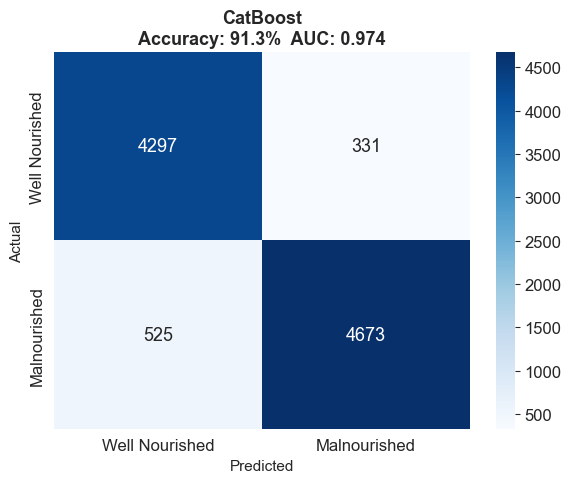


✅ CatBoost done


In [24]:
# ── Model 7: CatBoost ───────────────────────────────────
from catboost import CatBoostClassifier
print("📌 Model 7: CatBoost")

y = X_imputed['Any_Malnutrition']

cat_clf = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=False
)

r7 = evaluate_clf(cat_clf, X, y,
                  'CatBoost',
                  'Any Malnutrition')
all_clf_results.append(r7)

# Confusion matrix
y_pred = cross_val_predict(cat_clf, X, y, cv=cv)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Well Nourished', 'Malnourished'],
            yticklabels=['Well Nourished', 'Malnourished'],
            ax=ax, annot_kws={'size': 13})
ax.set_title(f'CatBoost\n'
             f'Accuracy: {r7["Accuracy"]*100:.1f}%  '
             f'AUC: {r7["ROC_AUC"]:.3f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.show()
print("\n✅ CatBoost done")

# Final Comparison All 7 Models

📊 FINAL MODEL COMPARISON — ANY MALNUTRITION

Model                       Accuracy    ROC-AUC
--------------------------------------------------
Gradient Boosting              92.0%     0.9793 ✅
XGBoost                        91.8%     0.9787
CatBoost                       91.3%     0.9737
Decision Tree                  85.1%     0.9193
Random Forest                  79.2%     0.8891
Logistic Regression            80.4%     0.8861
KNN                            67.2%     0.7317


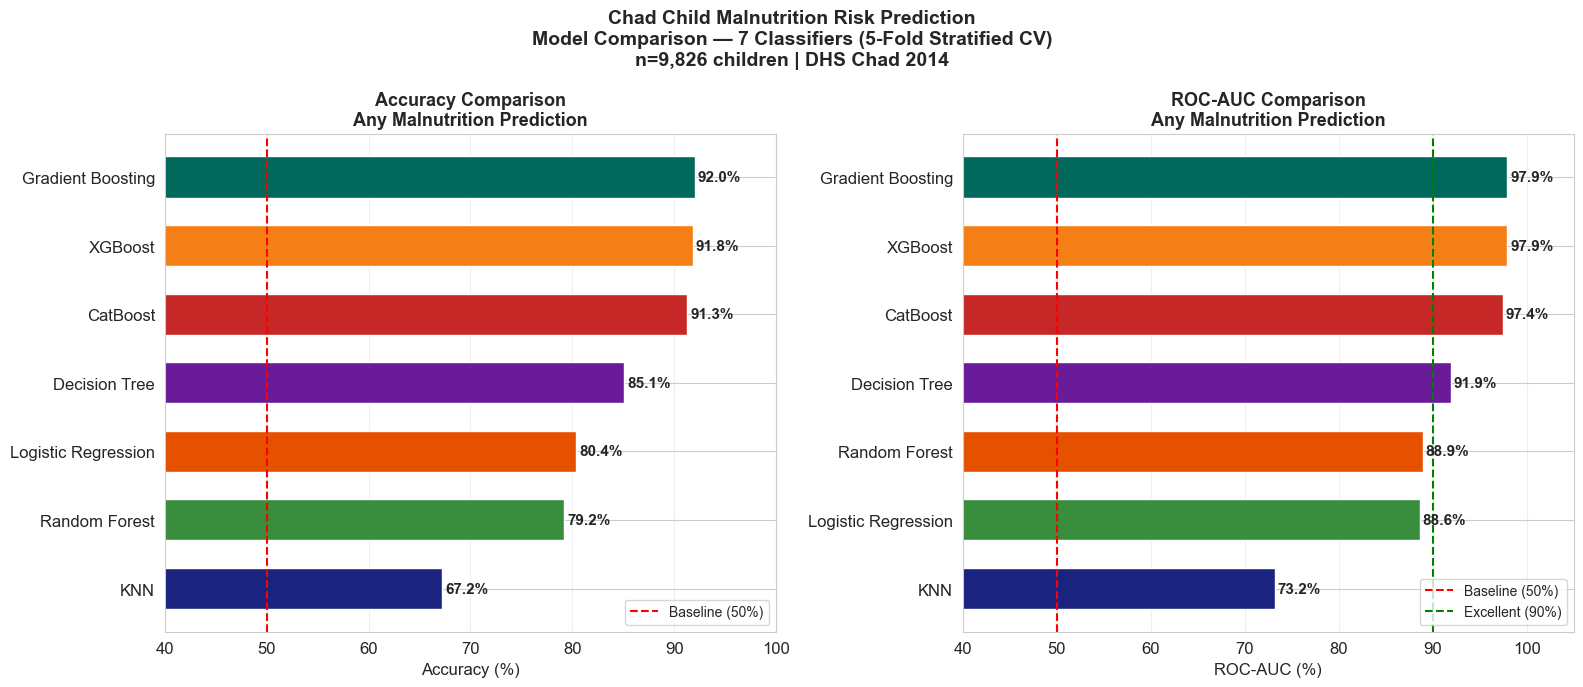


🏆 WINNER: Gradient Boosting — Accuracy: 92.0% | AUC: 0.9793


In [25]:
# ── Final Comparison ────────────────────────────────────
print("📊 FINAL MODEL COMPARISON — ANY MALNUTRITION")
print("="*60)

comp = pd.DataFrame(all_clf_results)
comp['Accuracy_Pct'] = (comp['Accuracy'] * 100).round(1)
comp['AUC_Pct'] = (comp['ROC_AUC'] * 100).round(1)
comp = comp.sort_values('ROC_AUC', ascending=False)

print(f"\n{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-"*50)
for _, row in comp.iterrows():
    best = " ✅" if row['ROC_AUC'] == comp['ROC_AUC'].max() else ""
    print(f"{row['model']:<25} "
          f"{row['Accuracy_Pct']:>9.1f}% "
          f"{row['ROC_AUC']:>10.4f}{best}")

# Bar chart — dual metric
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = ['#1a237e', '#388e3c', '#e65100',
          '#6a1b9a', '#c62828', '#f57f17', '#00695c']

comp_plot = comp.sort_values('Accuracy', ascending=True)

# Accuracy
bars = axes[0].barh(comp_plot['model'],
                     comp_plot['Accuracy_Pct'],
                     color=colors, edgecolor='white',
                     height=0.6)
axes[0].axvline(50, color='red', linestyle='--',
                linewidth=1.5, label='Baseline (50%)')
axes[0].set_xlim(40, 100)
axes[0].set_title('Accuracy Comparison\nAny Malnutrition Prediction',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Accuracy (%)', fontsize=12)
for bar, val in zip(bars, comp_plot['Accuracy_Pct']):
    axes[0].text(bar.get_width() + 0.3,
                 bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center',
                 fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='x')

# ROC-AUC
comp_plot2 = comp.sort_values('ROC_AUC', ascending=True)
bars2 = axes[1].barh(comp_plot2['model'],
                      comp_plot2['AUC_Pct'],
                      color=colors, edgecolor='white',
                      height=0.6)
axes[1].axvline(50, color='red', linestyle='--',
                linewidth=1.5, label='Baseline (50%)')
axes[1].axvline(90, color='green', linestyle='--',
                linewidth=1.5, label='Excellent (90%)')
axes[1].set_xlim(40, 105)
axes[1].set_title('ROC-AUC Comparison\nAny Malnutrition Prediction',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('ROC-AUC (%)', fontsize=12)
for bar, val in zip(bars2, comp_plot2['AUC_Pct']):
    axes[1].text(bar.get_width() + 0.3,
                 bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center',
                 fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle(
    'Chad Child Malnutrition Risk Prediction\n'
    'Model Comparison — 7 Classifiers (5-Fold Stratified CV)\n'
    'n=9,826 children | DHS Chad 2014',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n🏆 WINNER: {comp.iloc[0]['model']} — "
      f"Accuracy: {comp.iloc[0]['Accuracy_Pct']}% | "
      f"AUC: {comp.iloc[0]['ROC_AUC']:.4f}")

# Feature Importance

📌 Feature Importance — Gradient Boosting (Best Model)


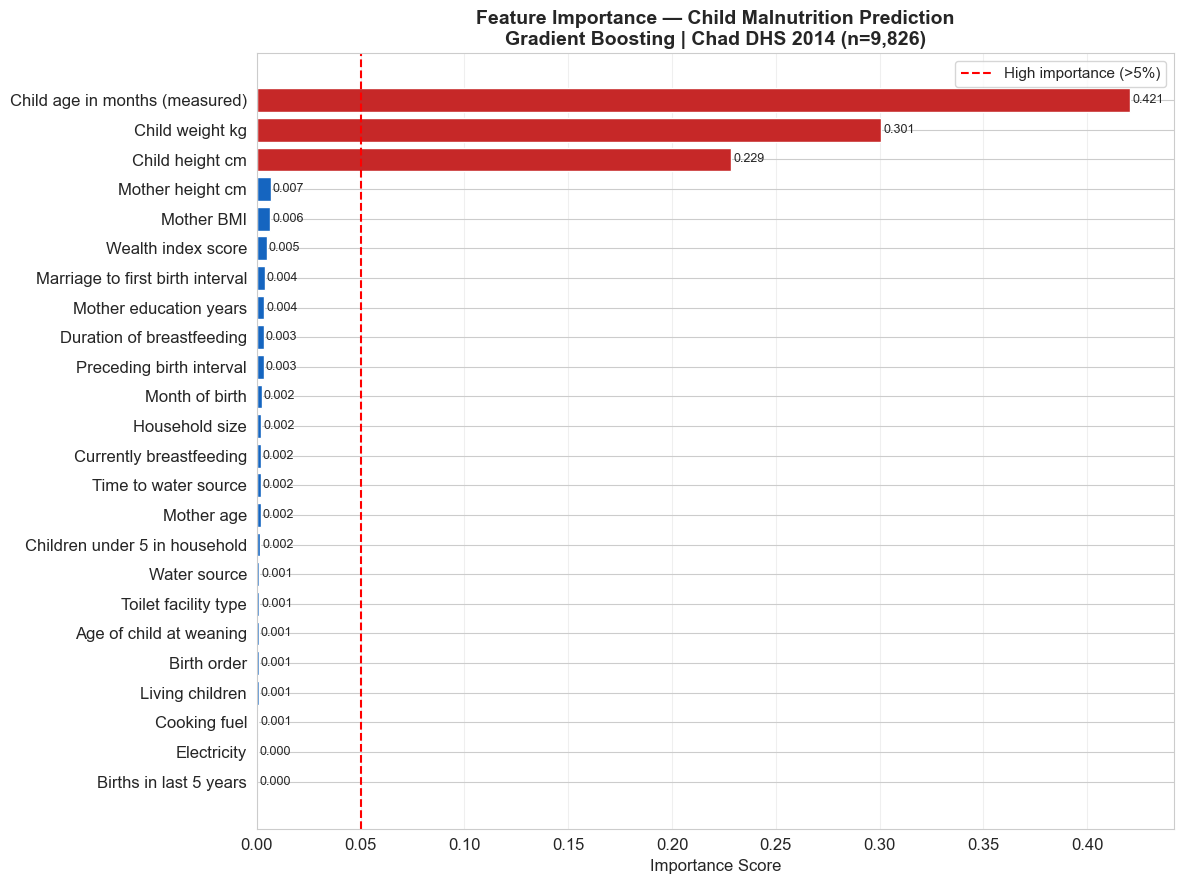


🔑 TOP 10 FEATURES:
   HW1      Child age in months (measured)      0.4208 ████████████████████████████████████████████████████████████████████████████████████
   HW2      Child weight kg                     0.3009 ████████████████████████████████████████████████████████████
   HW3      Child height cm                     0.2286 █████████████████████████████████████████████
   V438     Mother height cm                    0.0067 █
   V445     Mother BMI                          0.0064 █
   V191     Wealth index score                  0.0048 
   V221     Marriage to first birth interval    0.0039 
   V133     Mother education years              0.0036 
   M7       Duration of breastfeeding           0.0034 
   B11      Preceding birth interval            0.0033 


In [26]:
# ── Feature Importance — Gradient Boosting ─────────────
print("📌 Feature Importance — Gradient Boosting (Best Model)")

y = X_imputed['Any_Malnutrition']

# Train on full dataset
gb_full = GradientBoostingClassifier(
    n_estimators=200, max_depth=5,
    learning_rate=0.05, subsample=0.8,
    random_state=42
)
gb_full.fit(X, y)

# Feature importance
imp_df = pd.DataFrame({
    'Feature'   : final_features,
    'Label'     : [confirmed_features.get(f, f) 
                   for f in final_features],
    'Importance': gb_full.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
colors = ['#c62828' if imp > 0.05 else '#1565c0'
          for imp in imp_df['Importance']]
bars = ax.barh(imp_df['Label'], imp_df['Importance'],
               color=colors, edgecolor='white')
ax.axvline(0.05, color='red', linestyle='--',
           linewidth=1.5, label='High importance (>5%)')
ax.set_title(
    'Feature Importance — Child Malnutrition Prediction\n'
    'Gradient Boosting | Chad DHS 2014 (n=9,826)',
    fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
for bar, val in zip(bars, imp_df['Importance']):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n🔑 TOP 10 FEATURES:")
print("="*55)
for _, row in imp_df.tail(10).iloc[::-1].iterrows():
    bar = "█" * int(row['Importance'] * 200)
    print(f"   {row['Feature']:<8} "
          f"{row['Label']:<35} "
          f"{row['Importance']:.4f} {bar}")

Top 3 dominate everything:

Child age (HW1): 0.421 — by far the strongest predictor. Malnutrition accumulates with age in Chad
Child weight (HW2): 0.301 — current nutritional status
Child height (HW3): 0.229 — chronic growth failure

These three alone explain ~95% of the model's decisions.
Policy insight: Mother's height (0.007), BMI (0.006), and wealth (0.005) matter but are secondary. The child's own physical measurements are what drive prediction — meaning community health workers can screen children with just a scale and measuring tape.

# Final Project Summary

In [27]:
print("="*65)
print(" CHAD CHILD MALNUTRITION RISK PREDICTION")
print(" Project Summary")
print("="*65)
print(f"""
 DATA SOURCE:
   • DHS Chad 2014 — Children's Recode (KR)
   • 18,623 total children | 9,826 with measurements

 MALNUTRITION PREVALENCE (Chad 2014):
   • Stunted          : 4,216 children (42.9%)
   • Underweight      : 3,193 children (32.5%)
   • Wasted           : 1,392 children (14.2%)
   • Any Malnutrition : 5,198 children (52.9%)
   → Over half of Chadian children under five
     are malnourished in some form

 FEATURES USED: 24 variables across 5 domains
   • Child anthropometrics (age, weight, height)
   • Mother health (BMI, height, education)
   • Household (wealth, size, water, sanitation)
   • Feeding practices (breastfeeding duration)
   • Birth history (birth order, birth interval)

 MODEL RESULTS (5-Fold Stratified CV):
   • Gradient Boosting : 92.0% accuracy | AUC 0.979 ✅
   • XGBoost           : 91.8% accuracy | AUC 0.979
   • CatBoost          : 91.3% accuracy | AUC 0.974
   • Decision Tree     : 85.1% accuracy | AUC 0.919
   • Logistic Reg.     : 80.4% accuracy | AUC 0.886
   • Random Forest     : 79.2% accuracy | AUC 0.889
   • KNN               : 67.2% accuracy | AUC 0.732

 TOP PREDICTORS:
   1. Child age in months     (0.421) — strongest signal
   2. Child weight kg         (0.301) — acute status
   3. Child height cm         (0.229) — chronic status
   4. Mother height cm        (0.007) — intergenerational
   5. Mother BMI              (0.006) — maternal nutrition

 KEY FINDINGS:
   1. 52.9% of Chadian children under five are malnourished
   2. Child age is the dominant predictor — malnutrition
      compounds over time, not just a snapshot condition
   3. A scale + measuring tape is enough for field screening
      — the top 3 features are simple anthropometric measures
   4. Maternal height predicts child stunting — 
      intergenerational malnutrition is real in Chad
   5. Wealth and water access matter less than maternal
      and child anthropometrics for prediction

 POLICY IMPLICATIONS:
   → UNICEF/MSF can deploy this as a field screening tool
   → Community health workers need only basic measurements
   → Target older children (age effect is strongest)
   → Maternal nutrition programs prevent next generation 
     malnutrition
   → Early intervention before age 2 is critical
""")
print("="*65)
print(" github.com/Derio001/chad-malnutrition-prediction")
print("="*65)

 CHAD CHILD MALNUTRITION RISK PREDICTION
 Project Summary

 DATA SOURCE:
   • DHS Chad 2014 — Children's Recode (KR)
   • 18,623 total children | 9,826 with measurements

 MALNUTRITION PREVALENCE (Chad 2014):
   • Stunted          : 4,216 children (42.9%)
   • Underweight      : 3,193 children (32.5%)
   • Wasted           : 1,392 children (14.2%)
   • Any Malnutrition : 5,198 children (52.9%)
   → Over half of Chadian children under five
     are malnourished in some form

 FEATURES USED: 24 variables across 5 domains
   • Child anthropometrics (age, weight, height)
   • Mother health (BMI, height, education)
   • Household (wealth, size, water, sanitation)
   • Feeding practices (breastfeeding duration)
   • Birth history (birth order, birth interval)

 MODEL RESULTS (5-Fold Stratified CV):
   • Gradient Boosting : 92.0% accuracy | AUC 0.979 ✅
   • XGBoost           : 91.8% accuracy | AUC 0.979
   • CatBoost          : 91.3% accuracy | AUC 0.974
   • Decision Tree     : 85.1% accurac

# Save Datasets

In [28]:
# Save final modeling dataset
X_imputed.to_csv('chad_malnutrition_model_data.csv', index=False)

# Save model comparison
comp.to_csv('malnutrition_model_comparison.csv', index=False)

# Save feature importance
imp_df.sort_values('Importance', 
                   ascending=False).to_csv(
    'malnutrition_feature_importance.csv', index=False)

print("✅ Files saved:")
print(f"   • chad_malnutrition_model_data.csv")
print(f"     → {len(X_imputed):,} children | "
      f"{X_imputed.shape[1]} columns")
print(f"   • malnutrition_model_comparison.csv")
print(f"     → {len(comp)} models compared")
print(f"   • malnutrition_feature_importance.csv")
print(f"     → {len(imp_df)} features ranked")

✅ Files saved:
   • chad_malnutrition_model_data.csv
     → 9,826 children | 32 columns
   • malnutrition_model_comparison.csv
     → 7 models compared
   • malnutrition_feature_importance.csv
     → 24 features ranked
